## Samples

In [1]:
# sample_name = "samples_00243"
sample_name = "samples_000"
# sample_name = "samples_006"
# sample_name = "samples_007"
# sample_name = "samples_008"
# sample_name = "samples_009"
# sample_name = "samples_010"
# sample_name = "samples_011"

sample = sample_name.split("_")[1:]
sample = "_".join(sample)
print(sample)

000


In [2]:
!python3 super_pixel_generation.py --input_image="/data/akheirandish3/mvtec_ad/cable/test/bent_wire/{sample}.png" --output_dir="/home/akheirandish3/diffusion-posterior-sampling/figures"

Original shape: (256, 256, 3)
Original superpixels: 43
Saved to: /home/akheirandish3/diffusion-posterior-sampling/figures


In [3]:
import os
from glob import glob
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from skimage.metrics import structural_similarity as ssim


test_origin = "New_masking_half_sigma_batched"
test_origin = "Combined_half_sigma_batched"
# test_origin = "scar_small_sigma_batched"
label_image = io.imread(f"/home/akheirandish3/diffusion-posterior-sampling/results_patches/{sample_name}/{test_origin}_7_4/inpainting/label/0_00000.png")
label_image = np.mean(label_image[:,:,:3], axis=(2))
label_image_est = np.zeros_like(label_image)
# label_image = label_image[:,:,:3]
# Method 1: Using glob (recommended for pattern matching
patches = 24
dict_number_of_samples = {}
dict_z_core = {}
images_all = []
Z_score_list = []
mean_image = np.zeros((256, 256), dtype=np.float32)
std_image = np.zeros((256, 256), dtype=np.float32)
distance_image = np.zeros((256, 256), dtype=np.float32)
images_patch_dict = {}
images_recon_dict = {}
for item in range(patches):
    directory = f"/home/akheirandish3/diffusion-posterior-sampling/results_patches/{sample_name}/{test_origin}_{item}_4/inpainting/recon"
    # directory = f"/home/akheirandish3/diffusion-posterior-sampling/results_patches/samples_00015_out_pnegg/scar_second_{item}_4/{j}/inpainting/recon"
    # mask_directory = f"/home/akheirandish3/diffusion-posterior-sampling/data/mask.png"
    mask_directory = f"/home/akheirandish3/diffusion-posterior-sampling/figures/mask.png"
    mask = io.imread(mask_directory)
    
    mask_label = ((mask == item) | (mask == (item + 15)))
    
    # Get all PNG files
    image_paths = sorted(glob(os.path.join(directory, "*.png")))

    # Load all images
    images_list = []
    for path in image_paths:
        img = io.imread(path)
        # Handle RGBA -> RGB if needed
        if img.ndim == 3 and img.shape[-1] == 4:
            img = img[..., :3]
        images_list.append(img)
    images_all.extend(images_list)
    if images_list == []:
        print(f"No images found in {directory}, skipping...")
        continue
    # Convert to numpy array
    # temp = images[1]
    # images[1] = images[0]
    # images.append(temp)
    images = (np.array(images_list)) * mask_label[None, :, :, None]
    mask_label_1 = ((mask == item))
    
    mask_label_2 = (mask == (item+15))
    # Store masked images for each patch
    if item not in images_patch_dict:
        images_patch_dict[item] = images * mask_label_1[None, :, :, None]
    else:
        images_patch_dict[item] = np.concatenate(
            [images_patch_dict[item], images * mask_label_1[None, :, :, None]], axis=0
        )
    if (item+15) not in images_patch_dict:
        images_patch_dict[item+15] = images * mask_label_2[None, :, :, None]
    else:
        images_patch_dict[item+15] = np.concatenate(
            [images_patch_dict[item+15], images * mask_label_2[None, :, :, None]], axis=0
        )
    for test_i in range(50):
        mask_label_3 = ((mask == test_i))
        if (test_i != item) and (test_i != (item+15)):
            if (images_recon_dict.get(test_i) is None):
                images_recon_dict[test_i] = (np.array(images_list)) * mask_label_3[None, :, :, None]
            else:
                images_recon_dict[test_i] = np.concatenate(
                    [images_recon_dict[test_i], ((np.array(images_list)) )* mask_label_3[None, :, :, None]], axis=0
                )
# print((images_recon_dict[0]).shape)




No images found in /home/akheirandish3/diffusion-posterior-sampling/results_patches/samples_000/Combined_half_sigma_batched_0_4/inpainting/recon, skipping...
No images found in /home/akheirandish3/diffusion-posterior-sampling/results_patches/samples_000/Combined_half_sigma_batched_1_4/inpainting/recon, skipping...
No images found in /home/akheirandish3/diffusion-posterior-sampling/results_patches/samples_000/Combined_half_sigma_batched_2_4/inpainting/recon, skipping...
No images found in /home/akheirandish3/diffusion-posterior-sampling/results_patches/samples_000/Combined_half_sigma_batched_3_4/inpainting/recon, skipping...
No images found in /home/akheirandish3/diffusion-posterior-sampling/results_patches/samples_000/Combined_half_sigma_batched_4_4/inpainting/recon, skipping...
No images found in /home/akheirandish3/diffusion-posterior-sampling/results_patches/samples_000/Combined_half_sigma_batched_5_4/inpainting/recon, skipping...
No images found in /home/akheirandish3/diffusion-pos

In [4]:
# plt.imshow(images_recon_dict[33][28])
images_recon_dict[0].shape

(16, 256, 256, 3)

Initial superpixels: 43
Final superpixels:   1618


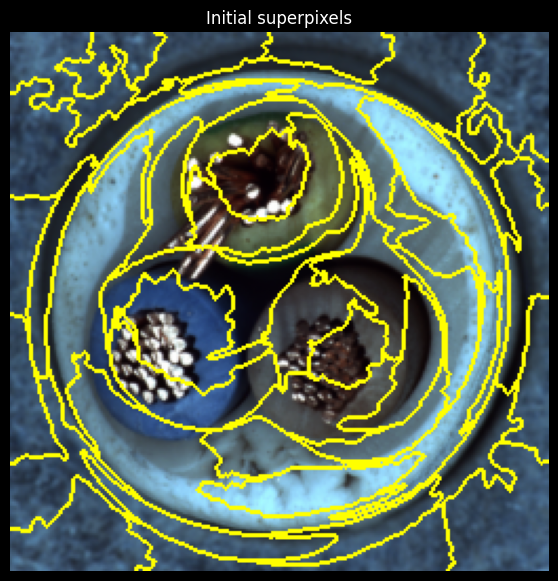

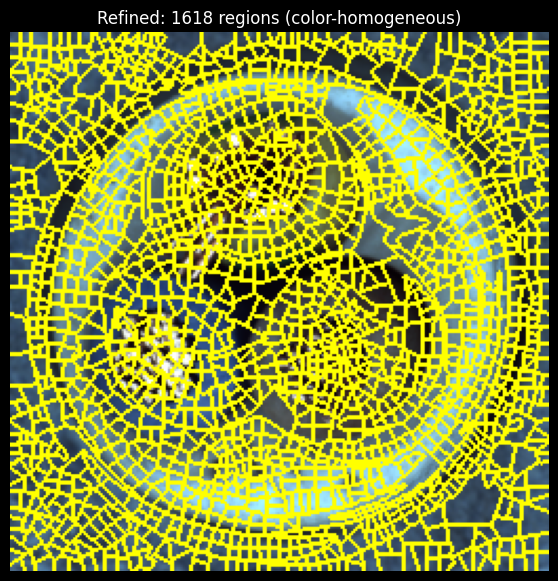

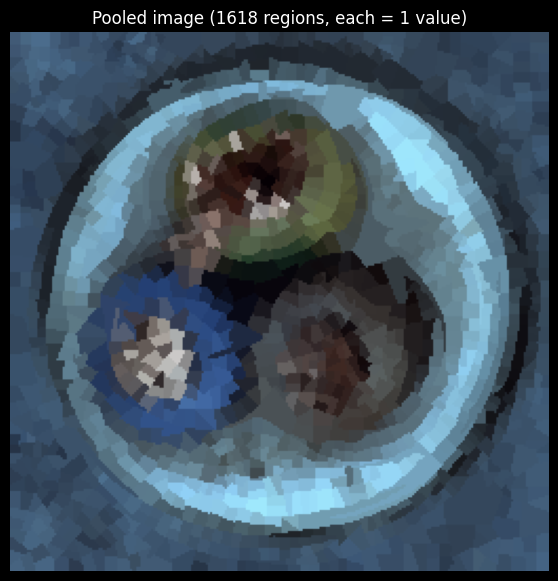


region_vals shape: (3041, 3)  (each row = one superpixel's RGB)
Example region 0: RGB = [52.356384 70.34574  91.547874]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Tuple, List, Dict
from skimage.util import img_as_float
from skimage.filters import sobel
from skimage.color import rgb2gray, rgb2lab
from skimage.segmentation import slic, find_boundaries


# -----------------------------
# 1) Color-homogeneity measure
# -----------------------------
def rgb_variance(img: np.ndarray, mask: np.ndarray) -> float:
    """Mean per-channel variance of RGB inside mask."""
    if mask.sum() == 0:
        return 0.0
    pix = img[mask]  # (n_pix, 3) or (n_pix,)
    if pix.ndim == 1:
        return float(np.var(pix))
    return float(np.mean([np.var(pix[:, c]) for c in range(pix.shape[1])]))


# -----------------------------
# 2) SLIC features with Lab + gradient
# -----------------------------
def slic_features_lab(img: np.ndarray, alpha_grad: float = 10.0) -> np.ndarray:
    img_f = img_as_float(img).astype(np.float32)
    if img_f.ndim == 2:
        g = sobel(img_f)
        return np.dstack([img_f, alpha_grad * g])
    lab = rgb2lab(img_f).astype(np.float32)
    gray = rgb2gray(img_f)
    g = sobel(gray).astype(np.float32)
    return np.dstack([lab, alpha_grad * g[..., None]])


# -----------------------------
# 3) Split one superpixel into n_sub pieces
# -----------------------------
def split_region(img: np.ndarray, full_mask: np.ndarray, region_id: int,
                 n_sub: int = 4, compactness: float = 8.0,
                 alpha_grad: float = 10.0) -> np.ndarray:
    """
    Split region_id in full_mask into n_sub sub-regions.
    Returns updated label map with new unique IDs.
    """
    m = (full_mask == region_id)
    if m.sum() < n_sub:
        return full_mask  # too small to split

    rows, cols = np.where(m)
    r0, r1 = rows.min(), rows.max() + 1
    c0, c1 = cols.min(), cols.max() + 1

    img_crop = img[r0:r1, c0:c1]
    m_crop = m[r0:r1, c0:c1]

    feats = slic_features_lab(img_crop, alpha_grad=alpha_grad)

    sub = slic(
        feats,
        n_segments=n_sub,
        compactness=compactness,
        sigma=0.5,
        start_label=0,
        mask=m_crop,
        channel_axis=-1,
    )

    new_labels = full_mask.copy()
    base = int(full_mask.max()) + 1
    rr, cc = np.where(m_crop)
    used = np.unique(sub[rr, cc])
    used = used[used >= 0]

    for i, u in enumerate(used):
        sel = (sub == u) & m_crop
        r_sel, c_sel = np.where(sel)
        new_labels[r0 + r_sel, c0 + c_sel] = base + i

    return new_labels


# -----------------------------
# 4) Recursive subdivide until color-homogeneous
# -----------------------------
def recursive_subdivide(
    img: np.ndarray,
    labels: np.ndarray,
    var_threshold: float = 150.0,      # max RGB variance to stop splitting
    min_pixels: int = 16,              # absolute minimum — don't fear small regions
    max_sub: int = 6,                  # split into this many pieces each time
    max_depth: int = 4,                # recursion depth limit
    compactness: float = 12.0,         # higher = more square sub-regions
    alpha_grad: float = 10.0,
    target_size: int = 200,            # desired pixels per final region (guides n_sub)
) -> Tuple[np.ndarray, List[int], Dict[int, List[int]]]:
    """
    Recursively split ALL superpixels until each sub-region has
    RGB variance < var_threshold or is smaller than min_pixels.

    Returns:
      labels_out: (H,W) refined label map
      final_ids:  list of all label IDs
      parent_map: original_id -> [child_ids] (recursive, only top-level parents)
    """

    labels_out = labels.copy().astype(np.int32)

    # Track parent->children for the original labels only
    orig_ids = list(np.unique(labels_out))
    parent_map = {int(oid): [int(oid)] for oid in orig_ids}

    def _get_descendants(parent_id):
        """Get current leaf IDs that descend from parent_id."""
        return parent_map.get(int(parent_id), [int(parent_id)])

    def _update_parent(orig_parent, old_child, new_children):
        children = parent_map[int(orig_parent)]
        children = [c for c in children if c != old_child]
        children.extend(new_children)
        parent_map[int(orig_parent)] = children

    # BFS queue: (region_id, depth, original_parent)
    from collections import deque
    queue = deque()
    for oid in orig_ids:
        queue.append((int(oid), 0, int(oid)))

    while queue:
        rid, depth, orig_parent = queue.popleft()

        m = (labels_out == rid)
        area = int(m.sum())

        if area < min_pixels or depth >= max_depth:
            continue

        v = rgb_variance(img, m)
        if v < var_threshold:
            continue

        # Decide how many sub-regions
        n_sub = max(2, min(max_sub, area // target_size))
        if n_sub < 2:
            continue

        old_max = int(labels_out.max())
        labels_out = split_region(
            img, labels_out, rid,
            n_sub=n_sub,
            compactness=compactness,
            alpha_grad=alpha_grad,
        )
        new_max = int(labels_out.max())

        if new_max == old_max:
            # split didn't produce new labels
            continue

        new_children = list(range(old_max + 1, new_max + 1))

        # If some pixels still have the old rid (shouldn't happen, but safety)
        if (labels_out == rid).sum() > 0:
            new_children.append(rid)

        _update_parent(orig_parent, rid, new_children)

        # Enqueue children for further splitting
        for child in new_children:
            if child != rid:
                queue.append((child, depth + 1, orig_parent))

    final_ids = sorted(list(np.unique(labels_out).astype(int)))
    return labels_out, final_ids, parent_map


# -----------------------------
# 5) Pool image: each region -> one RGB value (mean or median)
# -----------------------------
def pool_image(img: np.ndarray, labels: np.ndarray, reduce: str = "mean") -> Tuple[np.ndarray, np.ndarray]:
    """
    Replace every pixel with its region's mean/median RGB.
    Returns:
      pooled: (H,W,C) or (H,W) — same shape as img
      vals:   (K, C) or (K,) region values
    """
    lab = labels.astype(np.int32)
    K = int(lab.max()) + 1

    if img.ndim == 2:
        flat_lab = lab.ravel()
        flat_x = img.ravel().astype(np.float64)
        if reduce == "mean":
            sums = np.bincount(flat_lab, weights=flat_x, minlength=K)
            counts = np.maximum(np.bincount(flat_lab, minlength=K).astype(np.float64), 1.0)
            vals = (sums / counts).astype(np.float32)
        else:
            vals = np.zeros(K, dtype=np.float32)
            for k in range(K):
                m = (lab == k)
                if m.any():
                    vals[k] = np.median(img[m])
        return vals[lab], vals

    C = img.shape[-1]
    vals = np.zeros((K, C), dtype=np.float32)
    flat_lab = lab.ravel()
    counts = np.maximum(np.bincount(flat_lab, minlength=K).astype(np.float64), 1.0)

    if reduce == "mean":
        for c in range(C):
            sums = np.bincount(flat_lab, weights=img[..., c].ravel().astype(np.float64), minlength=K)
            vals[:, c] = (sums / counts).astype(np.float32)
    else:
        for k in range(K):
            m = (lab == k)
            if not m.any():
                continue
            for c in range(C):
                vals[k, c] = np.median(img[..., c][m])

    return vals[lab], vals


# -----------------------------
# 6) Visualization
# -----------------------------
def show_boundaries(img, labels, title="", linewidth=1):
    b = find_boundaries(labels, mode="thick")
    vis = img_as_float(img).copy()
    if vis.ndim == 2:
        vis[b] = 1.0
        cmap = "gray"
    else:
        vis[b, :] = [1.0, 1.0, 0.0]  # yellow boundaries
        cmap = None
    plt.figure(figsize=(7, 7))
    plt.imshow(vis, cmap=cmap)
    plt.axis("off")
    plt.title(title)
    plt.show()


# =============================
# USAGE
# =============================
from skimage import io

label_image = io.imread(
    f"/home/akheirandish3/diffusion-posterior-sampling/results_patches/"
    f"{sample_name}/{test_origin}_7_4/inpainting/label/0_00000.png"
)
label_image = label_image[:, :, :3]
img_test = np.zeros_like(label_image)

for i in range(50):
    img_test += (images_recon_dict[i]).mean(axis=0).astype(np.uint8)

labels0 = mask  # your initial superpixel label map

# --- Recursive color-homogeneous subdivision ---
labels_fine, final_ids, parent_map = recursive_subdivide(
    img=label_image,
    labels=labels0,
    var_threshold=60.0,   # lower = more splits (tighter color groups) 120 was the previous value 90 
    min_pixels=30,         # allow very small regions
    max_sub=6,             # pieces per split
    max_depth=4,           # recursion depth
    compactness=12.0,      # shape regularity (higher = more square)
    alpha_grad=10.0,       # edge-awareness in SLIC
    target_size=150,       # desired region size in pixels
)

print(f"Initial superpixels: {len(np.unique(labels0))}")
print(f"Final superpixels:   {len(final_ids)}")

show_boundaries(label_image, labels0, "Initial superpixels")
show_boundaries(label_image, labels_fine, f"Refined: {len(final_ids)} regions (color-homogeneous)")

# --- Pool: each region becomes one "pixel" value ---
pooled_img, region_vals = pool_image(label_image, labels_fine, reduce="mean")

plt.figure(figsize=(7, 7))
plt.imshow((pooled_img / 255.0).clip(0, 1))
plt.axis("off")
plt.title(f"Pooled image ({len(final_ids)} regions, each = 1 value)")
plt.show()

# --- Use region_vals as your "pixel" representation ---
# region_vals[i] = mean RGB of region i
# To get the region id for pixel (r,c): labels_fine[r, c]
# To get all pixels in region k: np.where(labels_fine == k)
print(f"\nregion_vals shape: {region_vals.shape}  (each row = one superpixel's RGB)")
print(f"Example region 0: RGB = {region_vals[final_ids[0]]}")

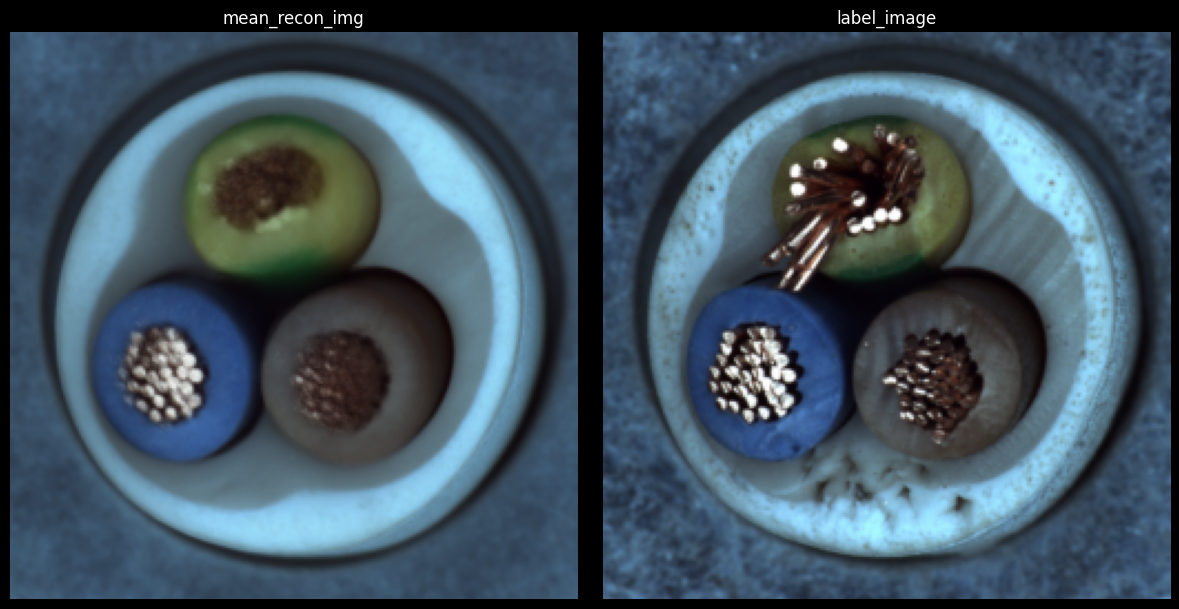

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# img_test_1 = np.zeros_like(label_image)
# for i in range(37):
#     img_test_1 += (images_patch_dict[i]).mean(axis=0).astype(np.uint8)
img_for_plot =  img_test

axes[0].imshow(img_for_plot)
axes[0].set_title("mean_recon_img")
axes[0].axis("off")
# axes[1].imshow(img_test_1)
# axes[1].set_title("mean_masked_img")
# axes[1].axis("off")
axes[1].imshow(label_image)
axes[1].set_title("label_image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
images_recon_dict[2].shape

(16, 256, 256, 3)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from typing import Dict, Tuple
from skimage.util import img_as_float
from skimage import io

# =============================
# Helpers
# =============================
def quantize_u8_to_bins(x_u8: np.ndarray, bins: int) -> np.ndarray:
    """Map [0,255] uint8 values to [0, bins-1] bin indices."""
    x = x_u8.astype(np.uint16)
    return ((x * bins) // 256).astype(np.uint8)


def rgb_pmf_joint(vals_rgb_q: np.ndarray, bins: int,
                  smooth_sigma: float = 1.0, eps: float = 1e-12) -> np.ndarray:
    """
    Build a joint 3D PMF of shape (bins, bins, bins) from quantized RGB values.
    vals_rgb_q: (M, 3) array of quantized bin indices.
    """
    r = vals_rgb_q[:, 0].astype(np.int64)
    g = vals_rgb_q[:, 1].astype(np.int64)
    b = vals_rgb_q[:, 2].astype(np.int64)

    idx = np.ravel_multi_index((r, g, b), dims=(bins, bins, bins))
    hist = np.bincount(idx, minlength=bins**3).astype(np.float64).reshape(bins, bins, bins)

    if smooth_sigma is not None and smooth_sigma > 0:
        hist = gaussian_filter(hist, sigma=smooth_sigma, mode="nearest")

    hist = hist + eps
    return hist / hist.sum()


def entropy_bits(pmf: np.ndarray, eps: float = 1e-12) -> float:
    """Shannon entropy H(P) in bits."""
    p = pmf.ravel()
    return float(-np.sum(p * np.log2(p + eps)))


def avg_neg_logp_bits(vals_rgb_q: np.ndarray, pmf: np.ndarray, eps: float = 1e-12) -> float:
    """-(1/n) sum log2 p(x_i) for a sequence of quantized RGB pixels."""
    r = vals_rgb_q[:, 0].astype(np.int64)
    g = vals_rgb_q[:, 1].astype(np.int64)
    b = vals_rgb_q[:, 2].astype(np.int64)
    p_x = pmf[r, g, b]
    return float(-np.mean(np.log2(p_x + eps)))


# =============================
# Typical set Δ per refined superpixel
# =============================
def compute_typical_set_refined(
    labels_fine: np.ndarray,             # (H, W) refined label map
    parent_map: Dict[int, list],         # original_id -> [child_ids]
    images_recon_dict: Dict[int, np.ndarray],  # orig_id -> (N, H, W, C) recon samples (ID distribution)
    images_patch_dict: Dict[int, np.ndarray],  # orig_id -> (N, H, W, C) patch samples (OOD, target)
    bins: int = 16,
    smooth_sigma: float = 1.0,
    min_pixels: int = 20,
    eps: float = 1e-12,
    use_label_as_target: bool = False,   # if True, use label_image as target instead of patch mean
    label_image: np.ndarray = None,      # (H, W, 3) ground truth label image
) -> Tuple[np.ndarray, Dict, list]:
    """
    For each refined superpixel:
      1. Build the joint RGB PMF from the *recon* samples (the in-distribution reference).
      2. Evaluate the *patch* (OOD) target sequence under that PMF.
      3. Compute Δ_sp = | -(1/n) log2 p(x^n) - H(P) |

    Higher Δ means the target sequence is farther from the typical set of the
    recon distribution → more likely OOD.

    Returns:
        delta_map:   (H, W) float array, Δ broadcasted per superpixel
        info:        dict[refined_id] -> {H_bits, avg_neg_logp_bits, delta_sp, ...}
        labels_used: sorted list of refined IDs that were processed
    """
    H_img, W_img = labels_fine.shape
    delta_map = np.full((H_img, W_img), np.nan, dtype=np.float32)
    info = {}
    labels_used = []

    # Reverse map: refined child -> original parent
    child_to_parent = {}
    for orig_id, children in parent_map.items():
        for child_id in children:
            child_to_parent[child_id] = orig_id

    all_refined_ids = sorted(np.unique(labels_fine).astype(int).tolist())

    for refined_id in all_refined_ids:
        orig_id = child_to_parent.get(refined_id, None)
        sp_mask = (labels_fine == refined_id)    # (H, W) boolean
        n_pix = int(sp_mask.sum())

        if n_pix < min_pixels:
            continue
        if orig_id is None:
            continue

        # -------------------------------------------------------
        # 1) Build ID PMF from recon samples at this superpixel
        # -------------------------------------------------------
        if orig_id not in images_recon_dict:
            continue
        recon_samples = images_recon_dict[orig_id]  # (N, H, W, C)
        if recon_samples.ndim != 4 or recon_samples.shape[-1] < 3:
            continue

        # Gather RGB values: (N, n_pix, 3) -> (N*n_pix, 3)
        recon_vals = recon_samples[:, sp_mask, :3].reshape(-1, 3).astype(np.uint8)
        if recon_vals.shape[0] == 0:
            continue

        recon_vals_q = quantize_u8_to_bins(recon_vals, bins=bins)
        pmf = rgb_pmf_joint(recon_vals_q, bins=bins, smooth_sigma=smooth_sigma, eps=eps)
        H_bits = entropy_bits(pmf, eps=eps)

        # -------------------------------------------------------
        # 2) Get the target (OOD) sequence for this superpixel
        # -------------------------------------------------------
        if use_label_as_target and label_image is not None:
            # Use ground truth label image
            if label_image.ndim == 2:
                # Grayscale -> fake RGB
                target_pixels = np.stack([label_image[sp_mask]] * 3, axis=-1).astype(np.uint8)
            else:
                target_pixels = label_image[sp_mask, :3].astype(np.uint8)  # (n_pix, 3)
        else:
            # Use mean of patch (OOD) samples as target sequence
            if orig_id not in images_patch_dict:
                continue
            patch_samples = images_patch_dict[orig_id]  # (N, H, W, C)
            if patch_samples.ndim != 4 or patch_samples.shape[-1] < 3:
                continue

            # Option A: use the mean image as the "observed" sequence
            patch_mean = np.mean(patch_samples[:, :, :, :3], axis=0).astype(np.uint8)  # (H, W, 3)
            target_pixels = patch_mean[sp_mask]  # (n_pix, 3)

        if target_pixels.shape[0] == 0:
            continue

        target_q = quantize_u8_to_bins(target_pixels, bins=bins)
        avg_nlogp = avg_neg_logp_bits(target_q, pmf, eps=eps)

        # -------------------------------------------------------
        # 3) Δ = | -(1/n) log2 p(x^n) - H |
        # -------------------------------------------------------
        delta_sp = float(np.abs(avg_nlogp - H_bits))

        # Broadcast to image
        delta_map[sp_mask] = delta_sp

        info[int(refined_id)] = {
            "orig_parent": int(orig_id),
            "num_pixels": n_pix,
            "H_bits": float(H_bits),
            "avg_neg_logp_bits": float(avg_nlogp),
            "delta_sp": float(delta_sp),
        }
        labels_used.append(int(refined_id))

    labels_used = sorted(labels_used)
    return delta_map, info, labels_used


# =============================
# Also compute Δ using ALL patch sample pixels (not just mean)
# for a per-sample typicality score
# =============================
def compute_typical_set_per_sample(
    labels_fine: np.ndarray,
    parent_map: Dict[int, list],
    images_recon_dict: Dict[int, np.ndarray],
    images_patch_dict: Dict[int, np.ndarray],
    bins: int = 16,
    smooth_sigma: float = 1.0,
    min_pixels: int = 20,
    eps: float = 1e-12,
) -> Tuple[np.ndarray, Dict, list]:
    """
    Same as above but evaluates EACH patch sample individually against the
    recon PMF, then takes the median Δ across samples.
    This is more robust to outlier samples.
    """
    H_img, W_img = labels_fine.shape
    delta_map = np.full((H_img, W_img), np.nan, dtype=np.float32)
    info = {}
    labels_used = []

    child_to_parent = {}
    for orig_id, children in parent_map.items():
        for child_id in children:
            child_to_parent[child_id] = orig_id

    all_refined_ids = sorted(np.unique(labels_fine).astype(int).tolist())

    for refined_id in all_refined_ids:
        orig_id = child_to_parent.get(refined_id, None)
        sp_mask = (labels_fine == refined_id)
        n_pix = int(sp_mask.sum())

        if n_pix < min_pixels or orig_id is None:
            continue
        if orig_id not in images_recon_dict or orig_id not in images_patch_dict:
            continue

        recon_samples = images_recon_dict[orig_id]
        patch_samples = images_patch_dict[orig_id]
        if recon_samples.ndim != 4 or recon_samples.shape[-1] < 3:
            continue
        if patch_samples.ndim != 4 or patch_samples.shape[-1] < 3:
            continue

        # Build PMF from recon
        recon_vals = recon_samples[:, sp_mask, :3].reshape(-1, 3).astype(np.uint8)
        if recon_vals.shape[0] == 0:
            continue
        recon_vals_q = quantize_u8_to_bins(recon_vals, bins=bins)
        pmf = rgb_pmf_joint(recon_vals_q, bins=bins, smooth_sigma=smooth_sigma, eps=eps)
        H_bits = entropy_bits(pmf, eps=eps)

        # Evaluate each patch sample individually
        N_patch = patch_samples.shape[0]
        deltas_per_sample = []
        for s in range(N_patch):
            target_pixels = patch_samples[s, sp_mask, :3].astype(np.uint8)  # (n_pix, 3)
            if target_pixels.shape[0] == 0:
                continue
            target_q = quantize_u8_to_bins(target_pixels, bins=bins)
            avg_nlogp = avg_neg_logp_bits(target_q, pmf, eps=eps)
            deltas_per_sample.append(float(np.abs(avg_nlogp - H_bits)))

        if len(deltas_per_sample) == 0:
            continue

        deltas_arr = np.array(deltas_per_sample)
        delta_sp_median = float(np.median(deltas_arr))
        delta_sp_mean = float(np.mean(deltas_arr))
        delta_sp_max = float(np.max(deltas_arr))

        delta_map[sp_mask] = delta_sp_median

        info[int(refined_id)] = {
            "orig_parent": int(orig_id),
            "num_pixels": n_pix,
            "H_bits": float(H_bits),
            "delta_median": delta_sp_median,
            "delta_mean": delta_sp_mean,
            "delta_max": delta_sp_max,
            "n_samples": N_patch,
        }
        labels_used.append(int(refined_id))

    labels_used = sorted(labels_used)
    return delta_map, info, labels_used


# =============================
# Visualization
# =============================
def plot_typical_set_results(delta_map, info, labels_used, img_test,
                             labels_fine, delta_threshold=None, title_prefix=""):
    fig, axes = plt.subplots(2, 3, figsize=(21, 12))

    # 1) Delta map
    im0 = axes[0, 0].imshow(delta_map, cmap='hot')
    axes[0, 0].set_title(f"{title_prefix}Δ map per superpixel")
    axes[0, 0].axis('off')
    plt.colorbar(im0, ax=axes[0, 0], label='Δ (bits)')

    # 2) Overlay on image
    vis = img_as_float(img_test).copy() if img_test.ndim == 3 else np.stack([img_as_float(img_test)]*3, axis=-1)
    delta_clean = np.nan_to_num(delta_map, nan=0.0)
    d_norm = delta_clean / (delta_clean.max() + 1e-8)
    overlay = vis.copy()
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.5 * d_norm, 0, 1)
    overlay[..., 1] = np.clip(overlay[..., 1] - 0.3 * d_norm, 0, 1)
    overlay[..., 2] = np.clip(overlay[..., 2] - 0.3 * d_norm, 0, 1)
    axes[0, 1].imshow(overlay)
    axes[0, 1].set_title(f"{title_prefix}Δ overlay (red = atypical = OOD)")
    axes[0, 1].axis('off')

    # 3) Binary typical/atypical mask
    if delta_threshold is not None:
        binary_mask = (delta_clean > delta_threshold).astype(np.float32)
        axes[0, 2].imshow(binary_mask, cmap='gray')
        axes[0, 2].set_title(f"Atypical mask (Δ > {delta_threshold:.2f})")
    else:
        # Use 90th percentile as auto threshold
        vals = delta_clean[delta_clean > 0]
        if len(vals) > 0:
            auto_thresh = np.percentile(vals, 90)
            binary_mask = (delta_clean > auto_thresh).astype(np.float32)
            axes[0, 2].imshow(binary_mask, cmap='gray')
            axes[0, 2].set_title(f"Atypical mask (Δ > {auto_thresh:.2f}, 90th pct)")
        else:
            axes[0, 2].set_title("No valid Δ values")
    axes[0, 2].axis('off')

    # 4) Histogram of Δ values
    deltas = np.array([info[l].get("delta_sp", info[l].get("delta_median", 0))
                       for l in labels_used])
    axes[1, 0].hist(deltas, bins=50, color='steelblue', alpha=0.8, edgecolor='black')
    if delta_threshold is not None:
        axes[1, 0].axvline(delta_threshold, color='red', linestyle='--', label=f'δ={delta_threshold}')
        axes[1, 0].legend()
    axes[1, 0].set_xlabel("Δ (bits)")
    axes[1, 0].set_ylabel("Count")
    axes[1, 0].set_title("Distribution of Δ across superpixels")

    # 5) Scatter: H vs Δ
    H_vals = np.array([info[l]["H_bits"] for l in labels_used])
    axes[1, 1].scatter(H_vals, deltas, s=10, alpha=0.6, c=deltas, cmap='hot')
    axes[1, 1].set_xlabel("H (entropy, bits)")
    axes[1, 1].set_ylabel("Δ (bits)")
    axes[1, 1].set_title("Entropy vs Δ per superpixel")
    if delta_threshold is not None:
        axes[1, 1].axhline(delta_threshold, color='red', linestyle='--', alpha=0.5)

    # 6) Sorted Δ values (rank plot)
    order = np.argsort(-deltas)
    axes[1, 2].plot(deltas[order], marker='o', markersize=2, linestyle='none', color='crimson')
    if delta_threshold is not None:
        axes[1, 2].axhline(delta_threshold, color='blue', linestyle='--', label=f'δ={delta_threshold}')
        axes[1, 2].legend()
    axes[1, 2].set_xlabel("Superpixel rank (high → low)")
    axes[1, 2].set_ylabel("Δ (bits)")
    axes[1, 2].set_title("Δ per superpixel (sorted)")

    plt.suptitle(f"{title_prefix}Typical Set OOD Detection — {len(labels_used)} superpixels", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Print stats
    print(f"\n{title_prefix}Δ stats across {len(deltas)} superpixels:")
    print(f"  Mean:   {deltas.mean():.4f}")
    print(f"  Median: {np.median(deltas):.4f}")
    print(f"  Max:    {deltas.max():.4f}  (SP {labels_used[order[0]]})")
    print(f"  Min:    {deltas.min():.4f}")
    print(f"  90th:   {np.percentile(deltas, 90):.4f}")
    if delta_threshold is not None:
        n_atypical = int((deltas > delta_threshold).sum())
        print(f"  Atypical (Δ > {delta_threshold}): {n_atypical}/{len(deltas)}")


# =============================
# RUN: Method 1 — Δ from mean of patch samples
# =============================
bins = 64
smooth_sigma = 1.0
delta_threshold = 0.5

# Load label image for optional use as target
label_image_rgb = io.imread(
    f"/home/akheirandish3/diffusion-posterior-sampling/results_patches/"
    f"{sample_name}/{test_origin}_7_4/inpainting/label/0_00000.png"
)[:, :, :3]

# =============================
print("\n" + "=" * 60)
print("Method 2: Δ using ground-truth label image as target")
print("=" * 60)
delta_map_label, info_label, labels_used_label = compute_typical_set_refined(
    labels_fine=labels_fine,
    parent_map=parent_map,
    images_recon_dict=images_recon_dict,
    images_patch_dict=images_patch_dict,
    bins=bins,
    smooth_sigma=smooth_sigma,
    min_pixels=20,
    use_label_as_target=True,
    label_image=label_image_rgb,
)

d = np.nan_to_num(delta_map_label, nan=0.0)



Method 2: Δ using ground-truth label image as target


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
# =============================
# 1) Load your binary anomaly mask
# =============================
# Adjust the path to your actual ground-truth anomaly mask
import numpy as np
import sys
import types
import PIL.Image as Image
# Patch: make numpy._core point to numpy.core so torch.load can unpickle
if not hasattr(np, '_core'):
    np._core = np.core
    # Also patch submodules that might be referenced
    for submod in ['multiarray', 'numeric', 'umath', 'fromnumeric', '_methods']:
        full_old = f'numpy.core.{submod}'
        full_new = f'numpy._core.{submod}'
        if full_old in sys.modules and full_new not in sys.modules:
            sys.modules[full_new] = sys.modules[full_old]
        elif hasattr(np.core, submod):
            sys.modules[full_new] = getattr(np.core, submod)

import torch
# sample_number = int(sample_name.split("_")[1])
# sample_number = 107
gt_mask_path = f"/data/akheirandish3/mvtec_ad/cable/ground_truth/combined/{sample}_mask.png"

mask = np.array(Image.open(gt_mask_path).convert("L"))  # grayscale

mask = mask[::4, ::4]  # downsample by factor of 4 (adjust as needed)
# Binarize: bright pixels = 1 (anomaly), dark pixels = 0 (background)
gt_mask_binary = (mask > 0).astype(np.uint8)


print(f"GT mask shape: {gt_mask_binary.shape}")
print(f"Anomalous pixels: {gt_mask_binary.sum()} / {gt_mask_binary.size} "
      f"({100 * gt_mask_binary.mean():.2f}%)")
import numpy as np
import matplotlib.pyplot as plt

# =============================
# Manual ROC / PR implementations (no sklearn needed)
# =============================
def manual_roc_curve(y_true, y_score):
    """Compute FPR, TPR for all thresholds."""
    desc_idx = np.argsort(-y_score)
    y_score = y_score[desc_idx]
    y_true = y_true[desc_idx]

    # Distinct thresholds
    distinct_idx = np.where(np.diff(y_score))[0]
    threshold_idx = np.concatenate([distinct_idx, [len(y_true) - 1]])

    tps = np.cumsum(y_true)[threshold_idx]
    fps = (threshold_idx + 1) - tps

    tps = np.concatenate([[0], tps])
    fps = np.concatenate([[0], fps])

    fpr = fps / fps[-1] if fps[-1] > 0 else fps
    tpr = tps / tps[-1] if tps[-1] > 0 else tps

    thresholds = y_score[threshold_idx]
    return fpr, tpr, thresholds


def manual_auc(x, y):
    """Trapezoidal AUC."""
    order = np.argsort(x)
    x, y = x[order], y[order]
    return float(np.trapz(y, x))


def manual_precision_recall_curve(y_true, y_score):
    """Compute precision, recall for all thresholds."""
    desc_idx = np.argsort(-y_score)
    y_score = y_score[desc_idx]
    y_true = y_true[desc_idx]

    tps = np.cumsum(y_true)
    fps = np.cumsum(1 - y_true)
    total_pos = y_true.sum()

    precision = tps / (tps + fps)
    recall = tps / total_pos if total_pos > 0 else tps

    # Prepend (recall=0, precision=1)
    precision = np.concatenate([[1.0], precision])
    recall = np.concatenate([[0.0], recall])
    thresholds = y_score

    return precision, recall, thresholds


def manual_average_precision(y_true, y_score):
    """Average precision (area under PR curve)."""
    precision, recall, _ = manual_precision_recall_curve(y_true, y_score)
    return float(-np.sum(np.diff(recall) * precision[:-1]))
# =============================
# 2) Map GT mask to superpixels: majority vote per sub-SP
# =============================
# sum_map is your additive Δ score map (H, W)
# labels_fine is your refined superpixel label map (H, W)

all_sp_ids = sorted(np.unique(labels_fine).astype(int).tolist())
delta_map_label_smooth = gaussian_filter(np.nan_to_num(delta_map_label, nan=0.0), sigma=20)
sp_scores = []   # anomaly score per superpixel (from sum_map)
sp_labels = []   # ground-truth label per superpixel (majority vote from gt_mask)
sp_ids_used = []

for sp_id in all_sp_ids:
    sp_mask = (labels_fine == sp_id)
    n_pix = int(sp_mask.sum())
    if n_pix < 1:
        continue

    # Anomaly score: mean of sum_map over this superpixel
    score = float(np.nanmean(delta_map_label[sp_mask]))
    if np.isnan(score):
        continue

    # Ground-truth: fraction of anomalous pixels in this superpixel
    frac_anomalous = gt_mask_binary[sp_mask].mean()

    # Majority vote: anomalous if > 50% of pixels are anomalous
    label = int(frac_anomalous > 0.5)

    sp_scores.append(score)
    sp_labels.append(label)
    sp_ids_used.append(sp_id)

sp_scores = np.array(sp_scores)
sp_labels = np.array(sp_labels)

print(f"\nSuperpixels used: {len(sp_scores)}")
print(f"Anomalous SPs: {sp_labels.sum()} / {len(sp_labels)} "
      f"({100 * sp_labels.mean():.2f}%)")

# =============================
# 3) Compute ROC and PR curves
# =============================
fpr, tpr, thresholds_roc = manual_roc_curve(sp_labels, sp_scores)
roc_auc = manual_auc(fpr, tpr)

precision, recall, thresholds_pr = manual_precision_recall_curve(sp_labels, sp_scores)
pr_auc = manual_average_precision(sp_labels, sp_scores)

# =============================
# 4) Also compute pixel-level AUC for comparison
# =============================
valid_mask = ~np.isnan(delta_map_label) if np.isnan(delta_map_label).any() else np.ones_like(delta_map_label, dtype=bool)
pixel_scores = delta_map_label[valid_mask].ravel()
pixel_labels = gt_mask_binary[valid_mask].ravel()

fpr_px, tpr_px, _ = manual_roc_curve(pixel_labels, pixel_scores)
roc_auc_px = manual_auc(fpr_px, tpr_px)

precision_px, recall_px, _ = manual_precision_recall_curve(pixel_labels, pixel_scores)
pr_auc_px = manual_average_precision(pixel_labels, pixel_scores)

# =============================
# 5) Plot
# =============================

GT mask shape: (256, 256)
Anomalous pixels: 2641 / 65536 (4.03%)

Superpixels used: 1453
Anomalous SPs: 69 / 1453 (4.75%)


/tmp/ipykernel_1119878/2681692991.py:120: RuntimeWarning: Mean of empty slice
  score = float(np.nanmean(delta_map_label[sp_mask]))


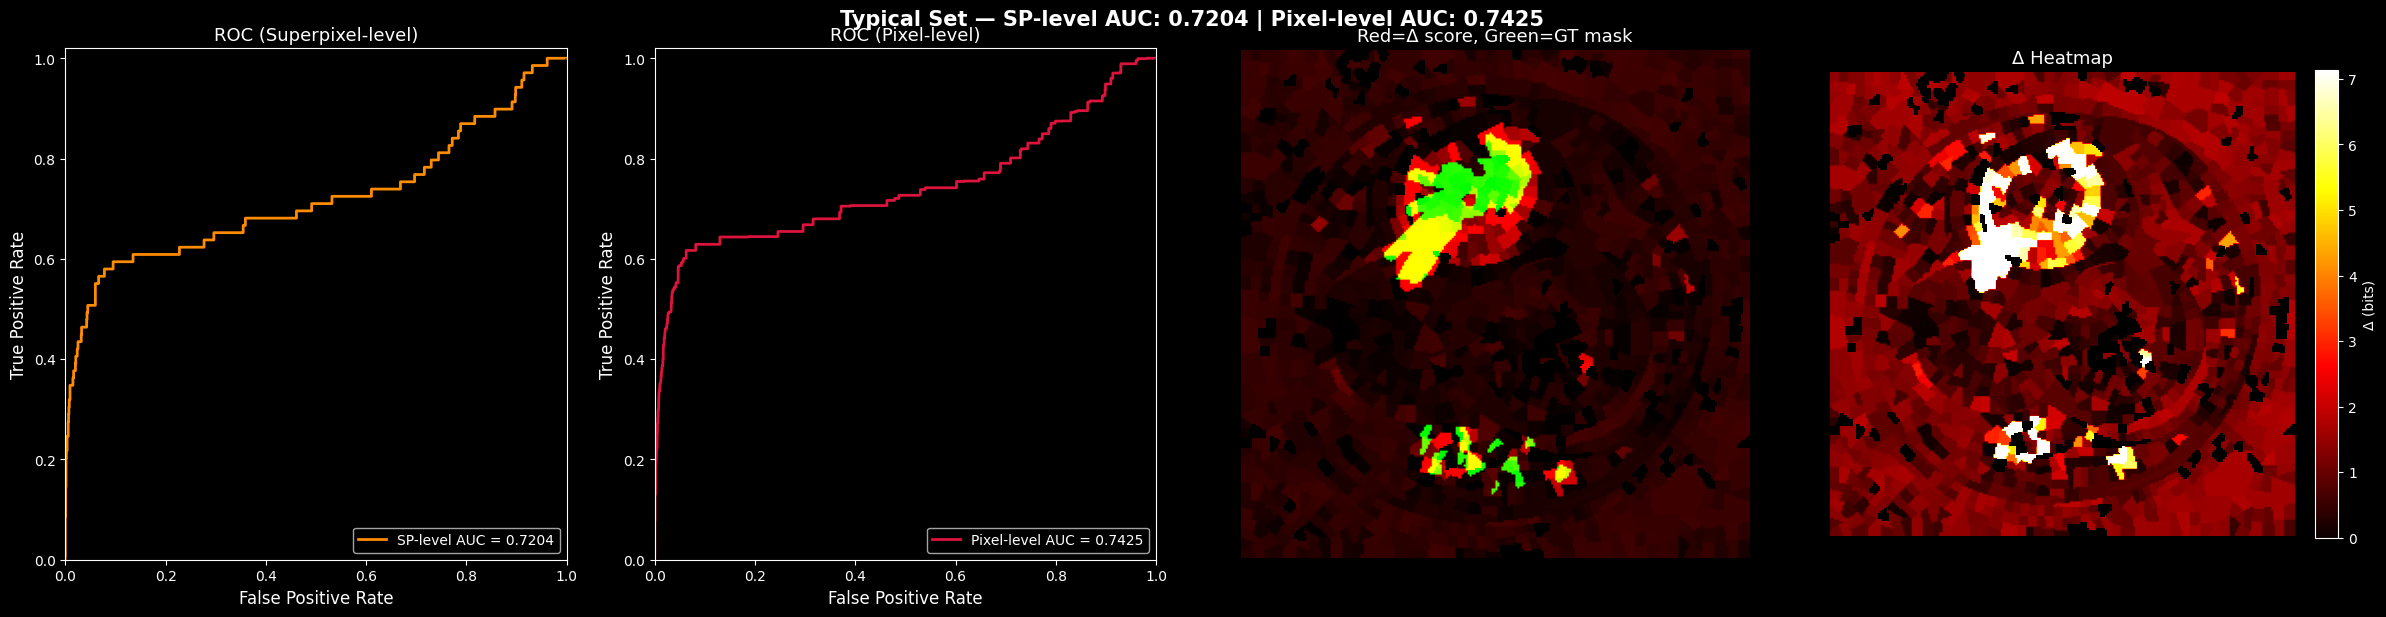


SUPERPIXEL-LEVEL:  ROC-AUC = 0.7204  |  AP = -0.4090
PIXEL-LEVEL:       ROC-AUC = 0.7425  |  AP = -0.4131


In [17]:
# Replace the plotting section (section 5) in the AUC analysis cell

from scipy.ndimage import gaussian_filter

# Optional: smooth delta map
# delta_smooth = gaussian_filter(np.nan_to_num(delta_map_label, nan=0.0), sigma=1.5)
delta_smooth = delta_map_label
# Clip outliers for better contrast
vmax_d = np.percentile(delta_smooth[delta_smooth > 0], 97) if (delta_smooth > 0).any() else 1.0

fig, axes = plt.subplots(1, 4, figsize=(24, 6),
                          gridspec_kw={'width_ratios': [1, 1, 1, 1]})

# --- 1) ROC: Superpixel-level ---
ax = axes[0]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'SP-level AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC (Superpixel-level)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_aspect('equal')

# --- 2) ROC: Pixel-level ---
ax = axes[1]
ax.plot(fpr_px, tpr_px, color='crimson', lw=2, label=f'Pixel-level AUC = {roc_auc_px:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC (Pixel-level)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_aspect('equal')

# --- 3) GT mask vs Δ overlay ---
ax = axes[2]
vis = np.zeros((*gt_mask_binary.shape, 3), dtype=np.float32)
sum_norm = np.clip(delta_smooth / (vmax_d + 1e-8), 0, 1)
vis[..., 0] = sum_norm                            # Red = high anomaly score
vis[..., 1] = gt_mask_binary.astype(np.float32)   # Green = GT anomaly
vis[..., 2] = 0
ax.imshow(np.clip(vis, 0, 1))
ax.set_title('Red=Δ score, Green=GT mask', fontsize=13)
ax.axis('off')

# --- 4) Heatmap of Δ scores ---
ax = axes[3]
im = ax.imshow(delta_smooth, cmap='hot', vmin=0, vmax=vmax_d)
ax.set_title('Δ Heatmap', fontsize=13)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Δ (bits)')

plt.suptitle(
    f"Typical Set — SP-level AUC: {roc_auc:.4f} | Pixel-level AUC: {roc_auc_px:.4f}",
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.show()

# =============================
# 6) Summary
# =============================
print(f"\n{'='*50}")
print(f"SUPERPIXEL-LEVEL:  ROC-AUC = {roc_auc:.4f}  |  AP = {pr_auc:.4f}")
print(f"PIXEL-LEVEL:       ROC-AUC = {roc_auc_px:.4f}  |  AP = {pr_auc_px:.4f}")
print(f"{'='*50}")

In [ ]:
sp_scores = []   # anomaly score per superpixel (from sum_map)
sp_labels = []   # ground-truth label per superpixel (majority vote from gt_mask)
sp_ids_used = []

for sp_id in all_sp_ids:
    sp_mask = (labels_fine == sp_id)
    n_pix = int(sp_mask.sum())
    if n_pix < 1:
        continue

    # Anomaly score: mean of sum_map over this superpixel
    score = float(np.nanmean(delta_map_label[sp_mask]))
    if np.isnan(score):
        continue

    # Ground-truth: fraction of anomalous pixels in this superpixel
    frac_anomalous = gt_mask_binary[sp_mask].mean()

    # Majority vote: anomalous if > 50% of pixels are anomalous
    label = int(frac_anomalous > 0.5)

    sp_scores.append(score)
    sp_labels.append(label)
    sp_ids_used.append(sp_id)

sp_scores = np.array(sp_scores)
sp_labels = np.array(sp_labels)

print(f"\nSuperpixels used: {len(sp_scores)}")
print(f"Anomalous SPs: {sp_labels.sum()} / {len(sp_labels)} "
      f"({100 * sp_labels.mean():.2f}%)")

# =============================
# 3) Compute ROC and PR curves
# =============================
fpr, tpr, thresholds_roc = manual_roc_curve(sp_labels, sp_scores)
roc_auc = manual_auc(fpr, tpr)

precision, recall, thresholds_pr = manual_precision_recall_curve(sp_labels, sp_scores)
pr_auc = manual_average_precision(sp_labels, sp_scores)

# =============================
# 4) Also compute pixel-level AUC for comparison
# =============================
valid_mask = ~np.isnan(delta_map_label) if np.isnan(delta_map_label).any() else np.ones_like(delta_map_label, dtype=bool)
pixel_scores = delta_map_label[valid_mask].ravel()
pixel_labels = gt_mask_binary[valid_mask].ravel()

fpr_px, tpr_px, _ = manual_roc_curve(pixel_labels, pixel_scores)
roc_auc_px = manual_auc(fpr_px, tpr_px)

precision_px, recall_px, _ = manual_precision_recall_curve(pixel_labels, pixel_scores)
pr_auc_px = manual_average_precision(pixel_labels, pixel_scores)


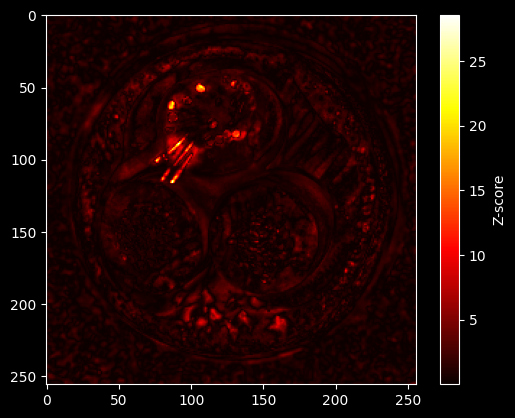

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# =============================
# 1) Build mean and std from recon samples
# =============================
mean_recon = np.zeros((256, 256, 3), dtype=np.float64)
std_recon = np.zeros((256, 256, 3), dtype=np.float64)
count_map = np.zeros((256, 256), dtype=np.float64)

for sp_id, recon_samples in images_recon_dict.items():
    # recon_samples: (N, H, W, C)
    if recon_samples.ndim != 4 or recon_samples.shape[-1] < 3:
        continue
    
    mask_directory = f"/home/akheirandish3/diffusion-posterior-sampling/figures/mask.png"
    mask_sp = io.imread(mask_directory)
    sp_mask = (mask_sp == sp_id)
    
    if sp_mask.sum() == 0:
        continue
    
    # Compute per-pixel mean and std from recon samples at this SP's pixels
    # recon_samples[:, sp_mask, :3] -> (N, n_pix, 3)
    vals = recon_samples[:, sp_mask, :3].astype(np.float64)  # (N, n_pix, 3)
    
    pixel_mean = np.mean(vals, axis=0)  # (n_pix, 3)
    pixel_std = np.std(vals, axis=0)    # (n_pix, 3)
    
    # Write back to spatial maps
    mean_recon[sp_mask] = pixel_mean
    std_recon[sp_mask] = pixel_std
    count_map[sp_mask] += 1

# Avoid division by zero
std_recon = np.where(std_recon < 1e-6, 1e-6, std_recon)

# =============================
# 2) Load GT label image (RGB)
# =============================
label_image_rgb = io.imread(
    f"/home/akheirandish3/diffusion-posterior-sampling/results_patches/"
    f"{sample_name}/{test_origin}_7_4/inpainting/label/0_00000.png"
)[:, :, :3].astype(np.float64)

# =============================
# 3) Compute Z-score: |GT - mean_recon| / std_recon
# =============================
z_score_rgb = np.abs(label_image_rgb - mean_recon) / std_recon  # (H, W, 3)
z_score_map = np.mean(z_score_rgb, axis=2)  # average across RGB channels -> (H, W)

# Only consider pixels that were covered by at least one SP
# z_score_map[count_map == 0] = 0.0

# =============================
# 4) Load GT anomaly mask and compute AUC
# =============================
sample_number = int(sample_name.split("_")[1])
# sample_number = 107
# gt_mask_path = f"./data/masks/mask_{sample_number}.png"
gt_mask = np.array(Image.open(gt_mask_path).convert("L"))
gt_mask_binary = (gt_mask > 0).astype(np.uint8)
gt_mask_binary = gt_mask_binary[::4, ::4]  # downsample to match z_score_map size (adjust as needed)

# Pixel-level AUC
# valid = (count_map > 0)
pixel_scores = z_score_map.ravel()
pixel_labels = gt_mask_binary.ravel()
plt.imshow(z_score_map, cmap='hot')
plt.colorbar(label='Z-score')

fpr_px, tpr_px, _ = manual_roc_curve(pixel_labels, pixel_scores)
roc_auc_px = manual_auc(fpr_px, tpr_px)

precision_px, recall_px, _ = manual_precision_recall_curve(pixel_labels, pixel_scores)
pr_auc_px = manual_average_precision(pixel_labels, pixel_scores)


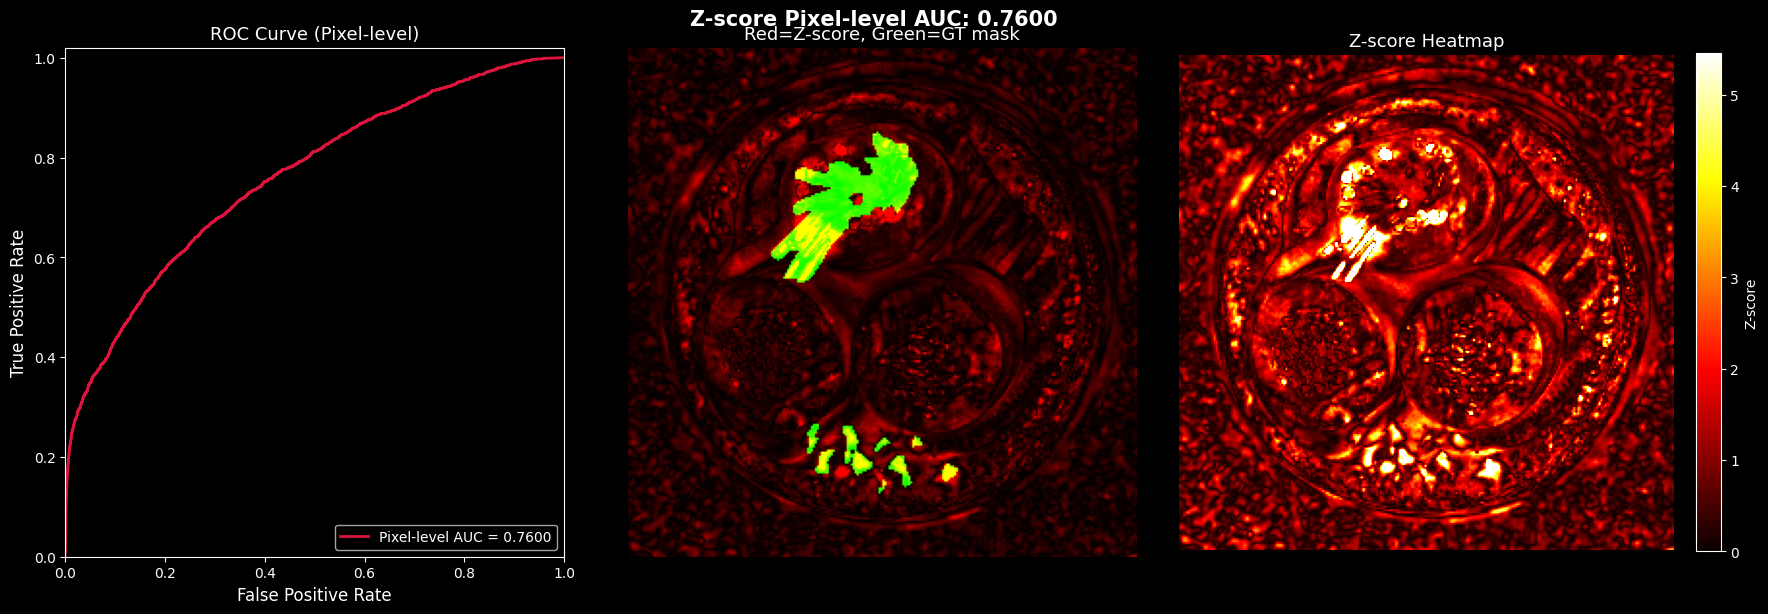

In [12]:
z_score_smooth = gaussian_filter(z_score_map, sigma=2.0)
z_score_smooth = z_score_map
# Clip outliers for better contrast
vmax_z = np.percentile(z_score_smooth[z_score_smooth > 0], 99) if (z_score_smooth > 0).any() else 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          gridspec_kw={'width_ratios': [1, 1, 1]})

# --- ROC pixel ---
ax = axes[0]
ax.plot(fpr_px, tpr_px, color='crimson', lw=2, label=f'Pixel-level AUC = {roc_auc_px:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve (Pixel-level)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_aspect('equal')

# --- GT mask vs Z-score overlay ---
ax = axes[1]
vis = np.zeros((*gt_mask_binary.shape, 3), dtype=np.float32)
sum_clean = np.nan_to_num(z_score_smooth, nan=0.0)
sum_norm = np.clip(sum_clean / (vmax_z + 1e-8), 0, 1)
vis[..., 0] = sum_norm                            # Red = high anomaly score
vis[..., 1] = gt_mask_binary.astype(np.float32)   # Green = GT anomaly
vis[..., 2] = 0
ax.imshow(np.clip(vis, 0, 1))
ax.set_title('Red=Z-score, Green=GT mask', fontsize=13)
ax.axis('off')

# --- Heatmap of Z-scores ---
ax = axes[2]
im = ax.imshow(z_score_smooth, cmap='hot', vmin=0, vmax=vmax_z)
ax.set_title('Z-score Heatmap', fontsize=13)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Z-score')

plt.suptitle(f"Z-score Pixel-level AUC: {roc_auc_px:.4f}", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()